In [156]:
#Importing Libraries
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [157]:
# ==============================
#        LOADING DATA
# ==============================

np.random.seed(42)

df = pd.read_csv("hybrid_energy_dataset_full_table.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")

In [158]:
# ==============================
#      FEATURE ENGINEERING
# ==============================
def features(data):
    df = data.copy()
    # Cyclic Encoding
    df["hour"] = df["Datetime"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["Solar_lag_1"] = df["Solar_Output_kW"].shift(1)
    df["Wind_lag_1"] = df["Wind_Output_kW"].shift(1)

    df["Solar_roll_3"] = df["Solar_Output_kW"].rolling(3).mean()
    df["Wind_roll_3"] = df["Wind_Output_kW"].rolling(3).mean()

    df = df.dropna()
    return df

df = features(df)

In [159]:
# ==============================
#           TARGETS
# ==============================

targets = ["Solar_Output_kW", "Wind_Output_kW","Total_Output_kW"]

X = df.drop(columns=targets + ["Datetime"])
y = df[targets]

# ==============================
#     TIME-BASED SPLITING
# ==============================

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

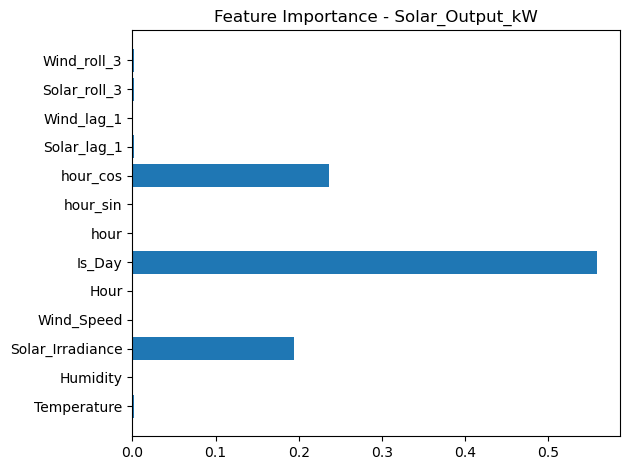

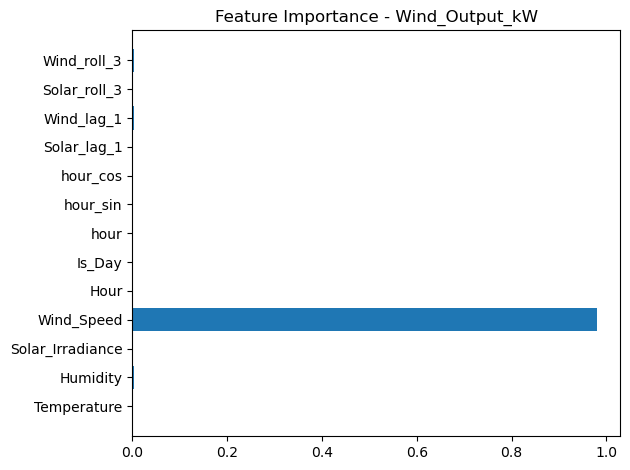

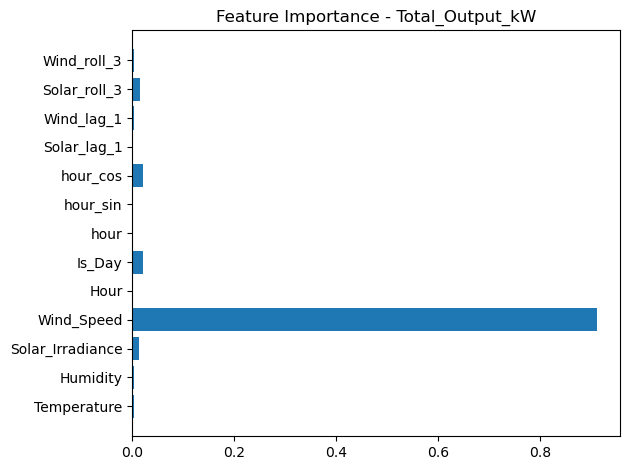

In [160]:
# ==============================
#      FEATURE IMPORTANCE
# ==============================

for target in targets:
    rf_pipeline = results[target]["Random Forest"]["model"]

    rf_model = rf_pipeline.named_steps["model"]
    importances = rf_model.feature_importances_
    feature_names = X.columns

    plt.figure()
    plt.barh(feature_names, importances)
    plt.title(f"Feature Importance - {target}")
    plt.tight_layout()
    plt.show()

In [161]:
# ==============================
#        BASELINE MODEL
# ==============================

def baseline_predict(y_series):
    return y_series.shift(1)

print("\n===== BASELINE PERFORMANCE =====")

for target in targets:
    baseline_preds = baseline_predict(y_test[target]).dropna()
    aligned_true = y_test[target].iloc[1:]

    mae = mean_absolute_error(aligned_true, baseline_preds)
    rmse = np.sqrt(mean_squared_error(aligned_true, baseline_preds))
    r2 = r2_score(aligned_true, baseline_preds)

    print(f"{target} Baseline")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    print("-" * 40)



===== BASELINE PERFORMANCE =====
Solar_Output_kW Baseline
MAE: 0.0288 | RMSE: 0.0489 | R2: 0.2803
----------------------------------------
Wind_Output_kW Baseline
MAE: 0.1857 | RMSE: 0.2478 | R2: -1.0131
----------------------------------------
Total_Output_kW Baseline
MAE: 0.1936 | RMSE: 0.2550 | R2: -0.9850
----------------------------------------


In [162]:
# ==============================
#     TRAINING & EVALUATING
# ==============================

results = {}

for target in targets:
    print(f"\n===== TARGET: {target} =====")
    results[target] = {}

    for name in ["Linear Regression", "Random Forest"]:

        if name == "Linear Regression":
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearRegression())
            ])
        else:
            model = Pipeline([
                ("model", RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    random_state=42,
                    n_jobs=-1
                ))
            ])

        model.fit(X_train, y_train[target])
        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test[target], preds)
        rmse = np.sqrt(mean_squared_error(y_test[target], preds))
        r2 = r2_score(y_test[target], preds)

        results[target][name] = {
            "model": model,
            "preds": preds,
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        }

        print(f"{name}")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R2: {r2:.4f}")
        print("-" * 30)


===== TARGET: Solar_Output_kW =====
Linear Regression
MAE: 0.0126
RMSE: 0.0160
R2: 0.9235
------------------------------
Random Forest
MAE: 0.0040
RMSE: 0.0071
R2: 0.9851
------------------------------

===== TARGET: Wind_Output_kW =====
Linear Regression
MAE: 0.0585
RMSE: 0.0714
R2: 0.8324
------------------------------
Random Forest
MAE: 0.0148
RMSE: 0.0257
R2: 0.9783
------------------------------

===== TARGET: Total_Output_kW =====
Linear Regression
MAE: 0.0576
RMSE: 0.0718
R2: 0.8417
------------------------------
Random Forest
MAE: 0.0195
RMSE: 0.0327
R2: 0.9671
------------------------------


In [163]:
# ==============================
# 8. CROSS VALIDATION
# ==============================

print("\n===== TIMESERIES CV (Random Forest) =====")

tscv = TimeSeriesSplit(n_splits=5)

for target in targets:
    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf,
        X,
        y[target],
        cv=tscv,
        scoring="neg_root_mean_squared_error"
    )

    print(f"{target} CV RMSE:", -scores.mean())


===== TIMESERIES CV (Random Forest) =====
Solar_Output_kW CV RMSE: 0.007265360862483114
Wind_Output_kW CV RMSE: 0.03193339177212493
Total_Output_kW CV RMSE: 0.03980410771511443


Evaluation for: Solar_Output_kW 


Model: Linear Regression | RMSE: 0.0160


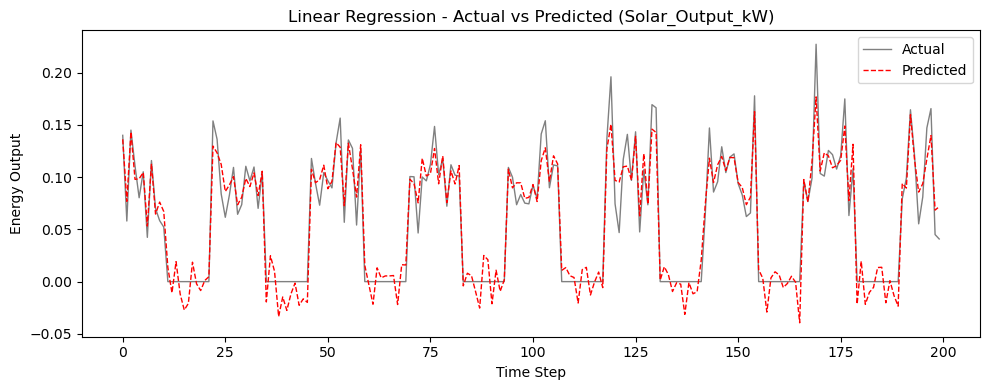

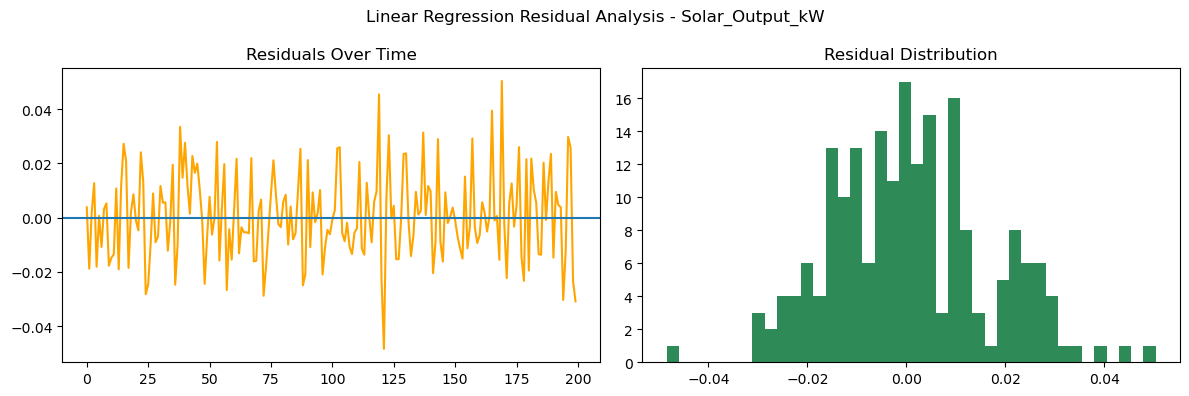


Model: Random Forest | RMSE: 0.0071


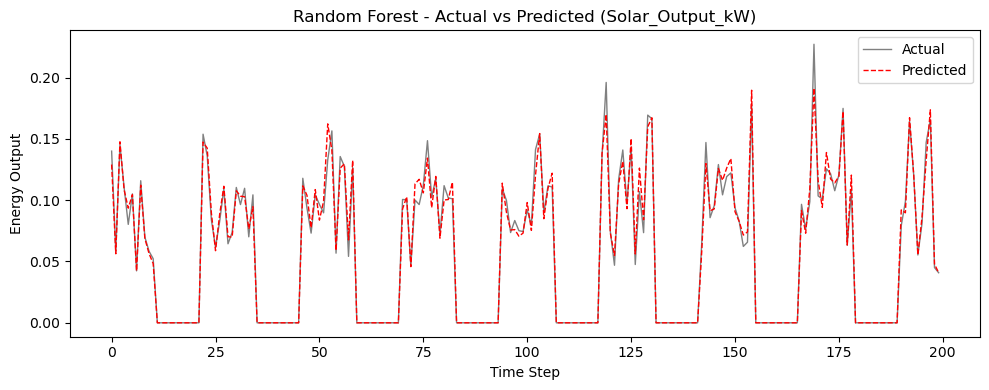

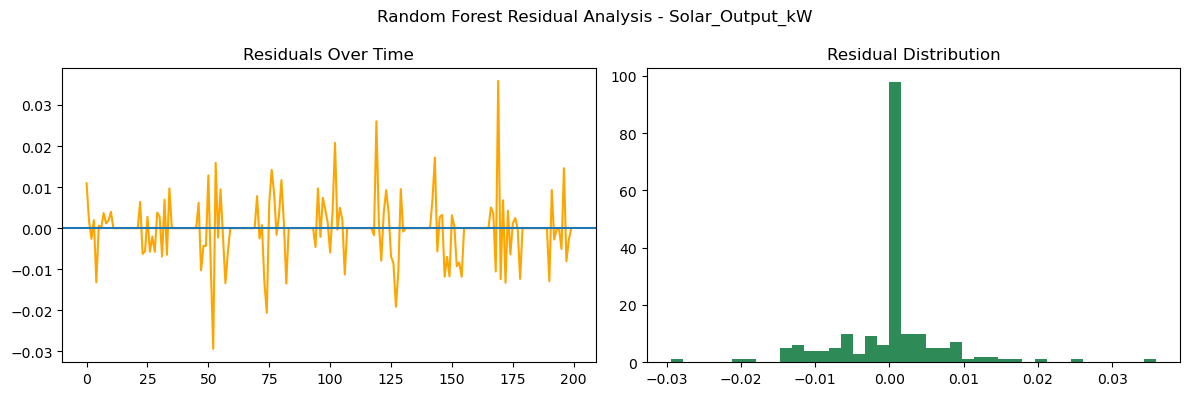

Evaluation for: Wind_Output_kW 


Model: Linear Regression | RMSE: 0.0714


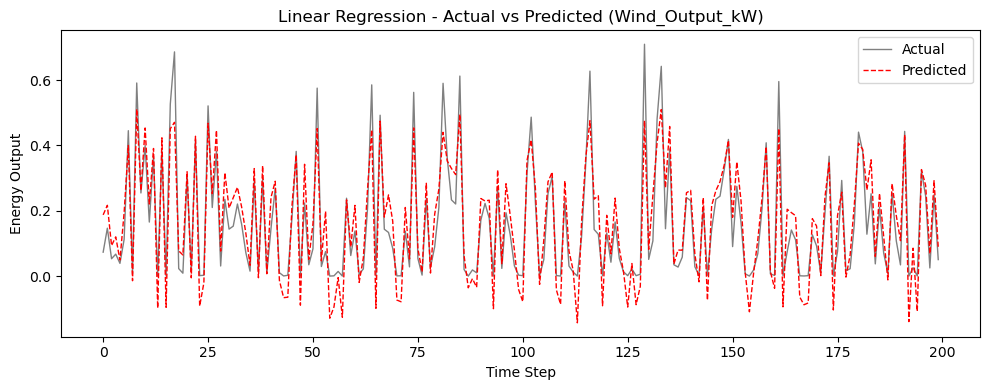

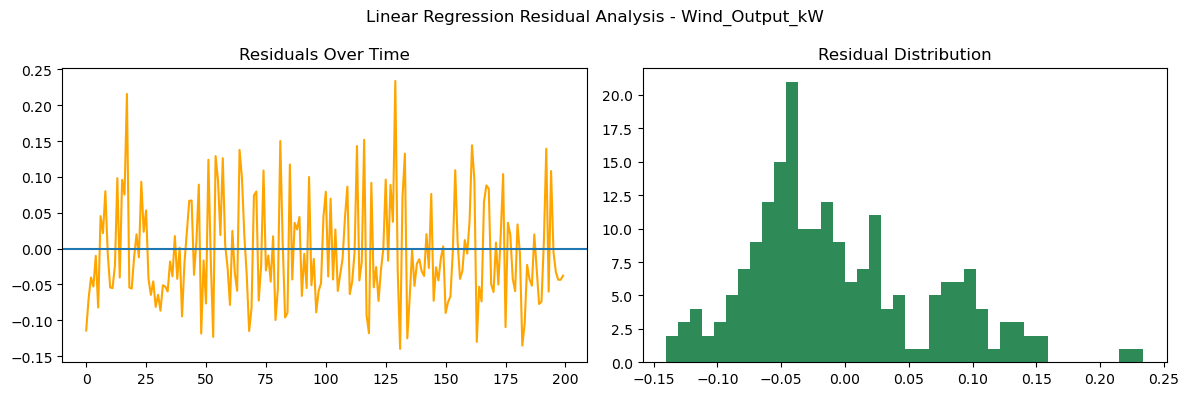


Model: Random Forest | RMSE: 0.0257


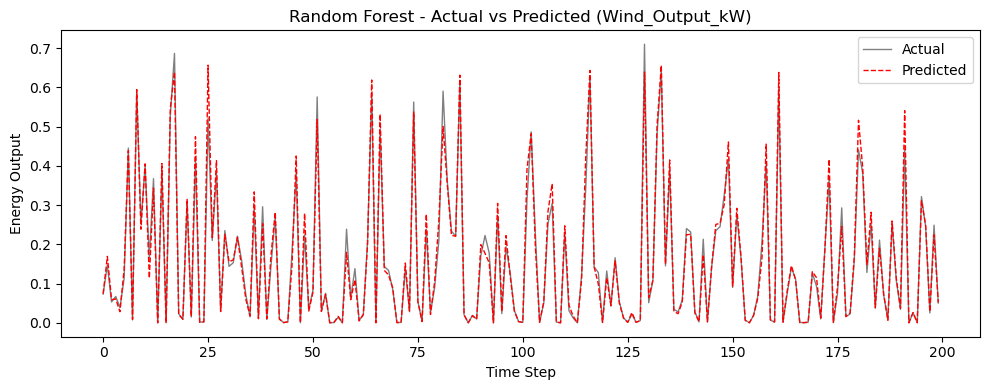

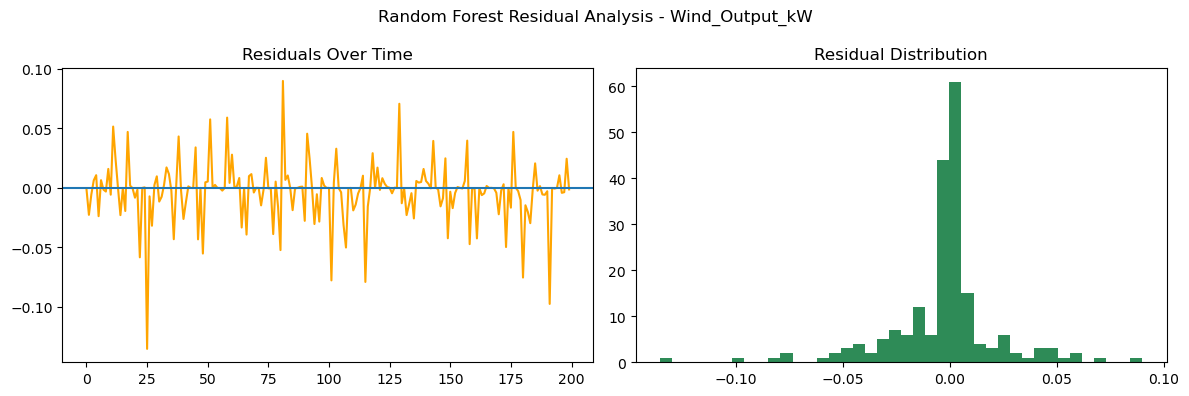

Evaluation for: Total_Output_kW 


Model: Linear Regression | RMSE: 0.0718


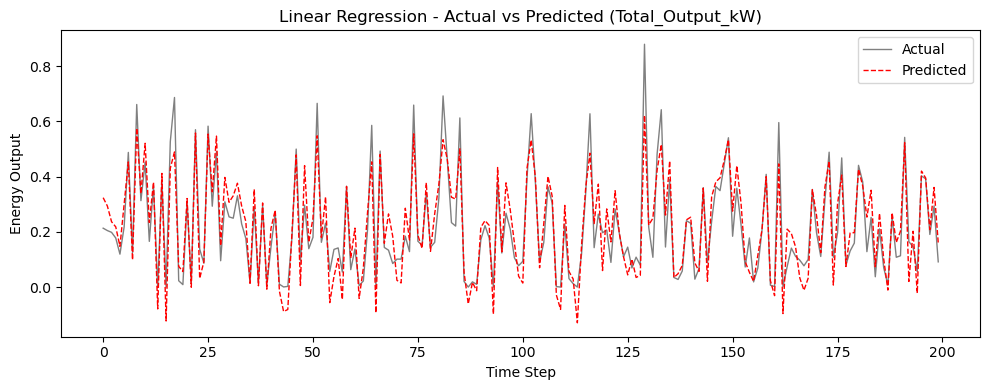

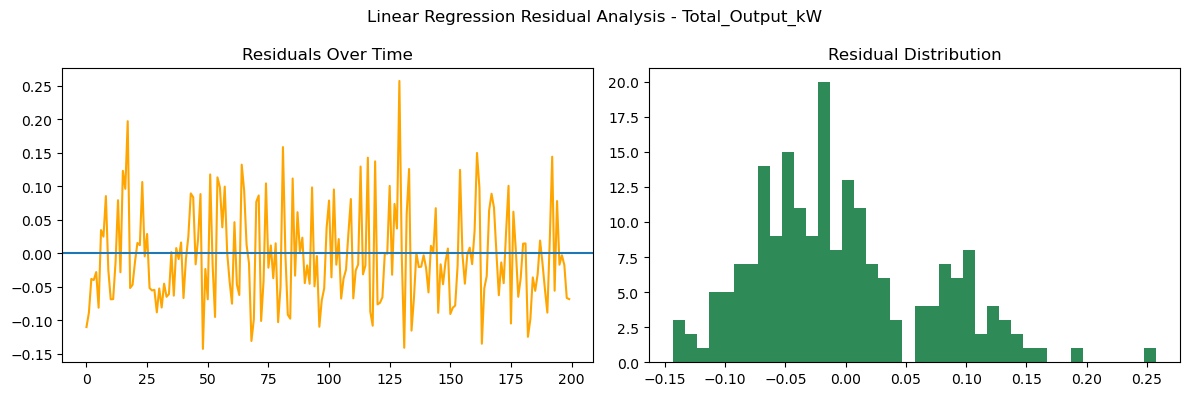


Model: Random Forest | RMSE: 0.0327


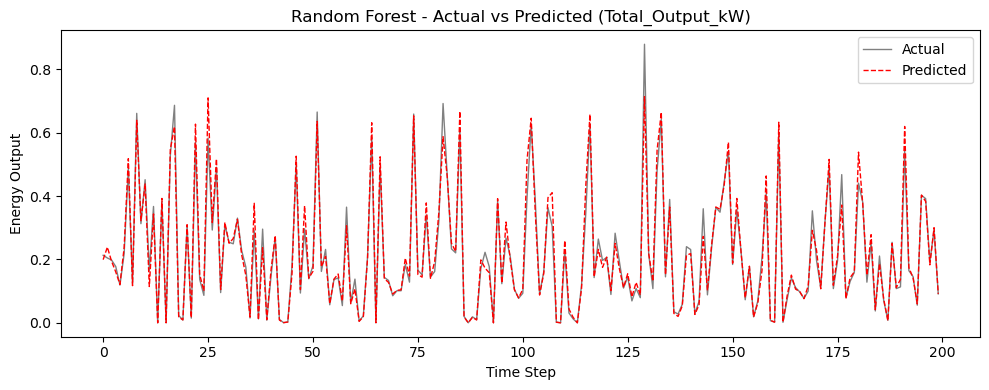

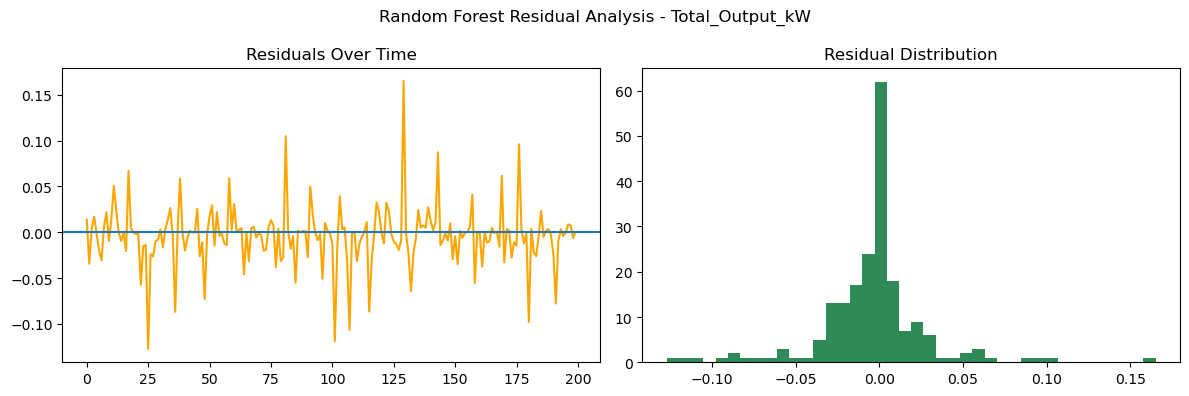

In [164]:
def evaluation(results, y_test, targets):

    for target in targets:

        print(f"Evaluation for: {target} \n")

        for model_name in results[target]:

            preds = results[target][model_name]["preds"]
            rmse = results[target][model_name]["rmse"]

            print(f"\nModel: {model_name} | RMSE: {rmse:.4f}")

            residuals = y_test[target].values - preds

            # ===============================
            # ACTUAL vs PREDICTED VALUES
            # ===============================
            plt.figure(figsize=(10,4))
            plt.plot(y_test[target].values, label="Actual", color='gray', linewidth=1)
            plt.plot(preds, label="Predicted", color='red', linestyle='--', linewidth=1)
            plt.title(f"{model_name} - Actual vs Predicted ({target})")
            plt.xlabel("Time Step")
            plt.ylabel("Energy Output")
            plt.legend()
            plt.tight_layout()
            plt.show()

            # ===============================
            # RESIDUAL ANALYSIS
            # ===============================
            fig, ax = plt.subplots(1, 2, figsize=(12,4))

            # Residuals over time
            ax[0].plot(residuals, color='orange')
            ax[0].axhline(0)
            ax[0].set_title("Residuals Over Time")

            # Residual distribution
            ax[1].hist(residuals, bins=40, color='seagreen')
            ax[1].set_title("Residual Distribution")

            plt.suptitle(f"{model_name} Residual Analysis - {target}")
            plt.tight_layout()
            plt.show()


evaluation(results, y_test, targets)

In [165]:
# ===============================
# SAVING TRAINED MODELS
# ===============================
os.makedirs("saved_models", exist_ok=True)

for target in results:
    for model_name in results[target]:

        model = results[target][model_name]["model"]

        filename = f"saved_models/{model_name.replace(' ', '_')}_{target}.pkl"
        joblib.dump(model, filename)

        print(f"Saved: {filename}")

print("\nAll models saved successfully.")

Saved: saved_models/Linear_Regression_Solar_Output_kW.pkl
Saved: saved_models/Random_Forest_Solar_Output_kW.pkl
Saved: saved_models/Linear_Regression_Wind_Output_kW.pkl
Saved: saved_models/Random_Forest_Wind_Output_kW.pkl
Saved: saved_models/Linear_Regression_Total_Output_kW.pkl
Saved: saved_models/Random_Forest_Total_Output_kW.pkl

All models saved successfully.
